In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = '/content/drive/MyDrive/sheet_music_reader/yolo_dataset.zip'
extract_path = '/content/yolo_dataset'

print("Extracting dataset")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')
print("Done")
print(os.listdir(extract_path))

Mounted at /content/drive
Extracting dataset...
Done
['labels', 'dataset.yaml', 'images']


In [3]:
!pip install ultralytics -q
from ultralytics import YOLO
print("Ultralytics installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics installed successfully


In [4]:
import yaml

yaml_path = '/content/yolo_dataset/dataset.yaml'

with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

config['path'] = '/content/yolo_dataset'
config['train'] = '/content/yolo_dataset/images/train'
config['val'] = '/content/yolo_dataset/images/val'

with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("dataset.yaml updated:")
with open(yaml_path, 'r') as f:
    print(f.read())

dataset.yaml updated:
names:
- noteheadBlackOnLine
- noteheadBlackInSpace
- noteheadHalfOnLine
- noteheadHalfInSpace
- noteheadWholeOnLine
- noteheadWholeInSpace
- ledgerLine
- stem
- beam
- flag8thDown
- flag8thUp
- flag16thDown
- flag16thUp
- restQuarter
- restHalf
- restWhole
- rest8th
- clefG
- clefF
- timeSig4
- timeSig3
- timeSig2
- timeSigCommon
- timeSigCutCommon
- accidentalSharp
- accidentalFlat
- accidentalNatural
- keySharp
- keyFlat
- augmentationDot
nc: 30
path: /content/yolo_dataset
train: /content/yolo_dataset/images/train
val: /content/yolo_dataset/images/val



In [5]:
model = YOLO('yolov8s.pt')  # small model, good balance of speed and accuracy

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=8,
    name='sheet_music_yolov8',
    project='/content/drive/MyDrive/sheet_music_reader/runs',
    save=True,
    patience=10,  # early stopping if no improvement for 10 epochs
    verbose=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sheet_music_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1903.8±1131.9 MB/s, size: 267.1 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 352 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 352/352 82.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 5.9s/it 2:11
                   all        352     220356      0.629      0.411      0.489      0.283
   noteheadBlackOnLine        342      34743      0.798      0.663      0.773      0.471
  noteheadBlackInSpace        340      33887      0.819      0.655      0.773      0.479
    noteheadHalfOnLine        242       2876      0.593       0.59      0.605      0.328
   noteheadHalfInSpace        232       2805       0.66      0.507      0.577      0.295
   noteheadWholeOnLine        134        865      0.487      0.703       0.62      0.343
  noteheadWholeInSpace        131  

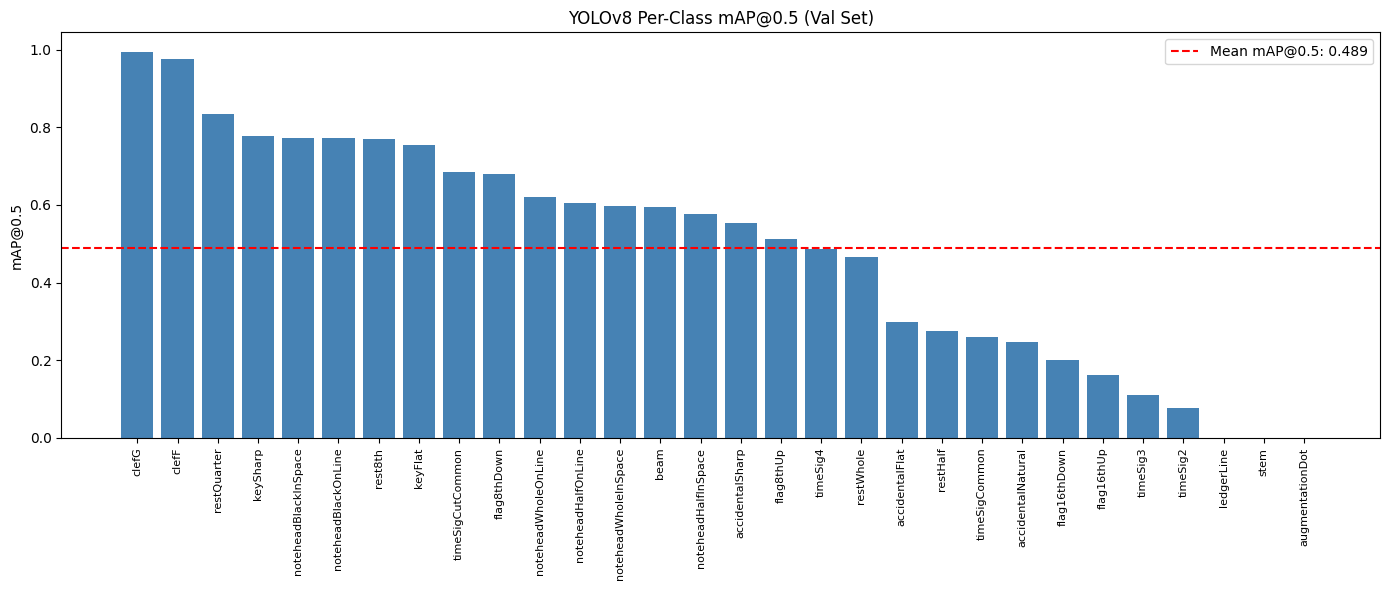

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Run validation to get per-class metrics
val_results = model.val(data='/content/yolo_dataset/dataset.yaml')

# Extract per-class AP50
class_names = val_results.names
maps = val_results.box.ap50  # per-class mAP@0.5

# Build dataframe
df = pd.DataFrame({
    'class': [class_names[i] for i in range(len(maps))],
    'mAP50': maps
}).sort_values('mAP50', ascending=False)

print(df.to_string(index=False))

# Plot
plt.figure(figsize=(14, 6))
bars = plt.bar(df['class'], df['mAP50'], color='steelblue')
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('mAP@0.5')
plt.title('YOLOv8 Per-Class mAP@0.5 (Val Set)')
plt.axhline(y=val_results.box.map50, color='red',
            linestyle='--', label=f'Mean mAP@0.5: {val_results.box.map50:.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sheet_music_reader/yolo_map_per_class.png',
            dpi=150, bbox_inches='tight')
plt.show()


image 1/1 /content/yolo_dataset/images/val/lg-45216451-aug-lilyjazz--page-3.png: 640x480 51 noteheadBlackOnLines, 58 noteheadBlackInSpaces, 13 noteheadHalfOnLines, 22 noteheadHalfInSpaces, 11 noteheadWholeOnLines, 9 noteheadWholeInSpaces, 1 beam, 4 flag8thUps, 3 restQuarters, 6 clefGs, 3 clefFs, 21 keySharps, 12.9ms
Speed: 2.9ms preprocess, 12.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/yolo_dataset/images/val/lg-177278865-aug-emmentaler--page-7.png: 640x480 37 noteheadBlackOnLines, 52 noteheadBlackInSpaces, 3 noteheadHalfOnLines, 8 beams, 10 flag8thUps, 3 restQuarters, 1 restHalf, 2 restWholes, 4 rest8ths, 6 clefGs, 2 clefFs, 2 timeSig4s, 1 timeSig3, 22 accidentalSharps, 12.1ms
Speed: 2.6ms preprocess, 12.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/yolo_dataset/images/val/lg-170729311424586813-aug-beethoven--page-3.png: 640x480 58 noteheadBlackOnLines, 54 noteheadBlackInSpaces, 10 noteheadHalfOn

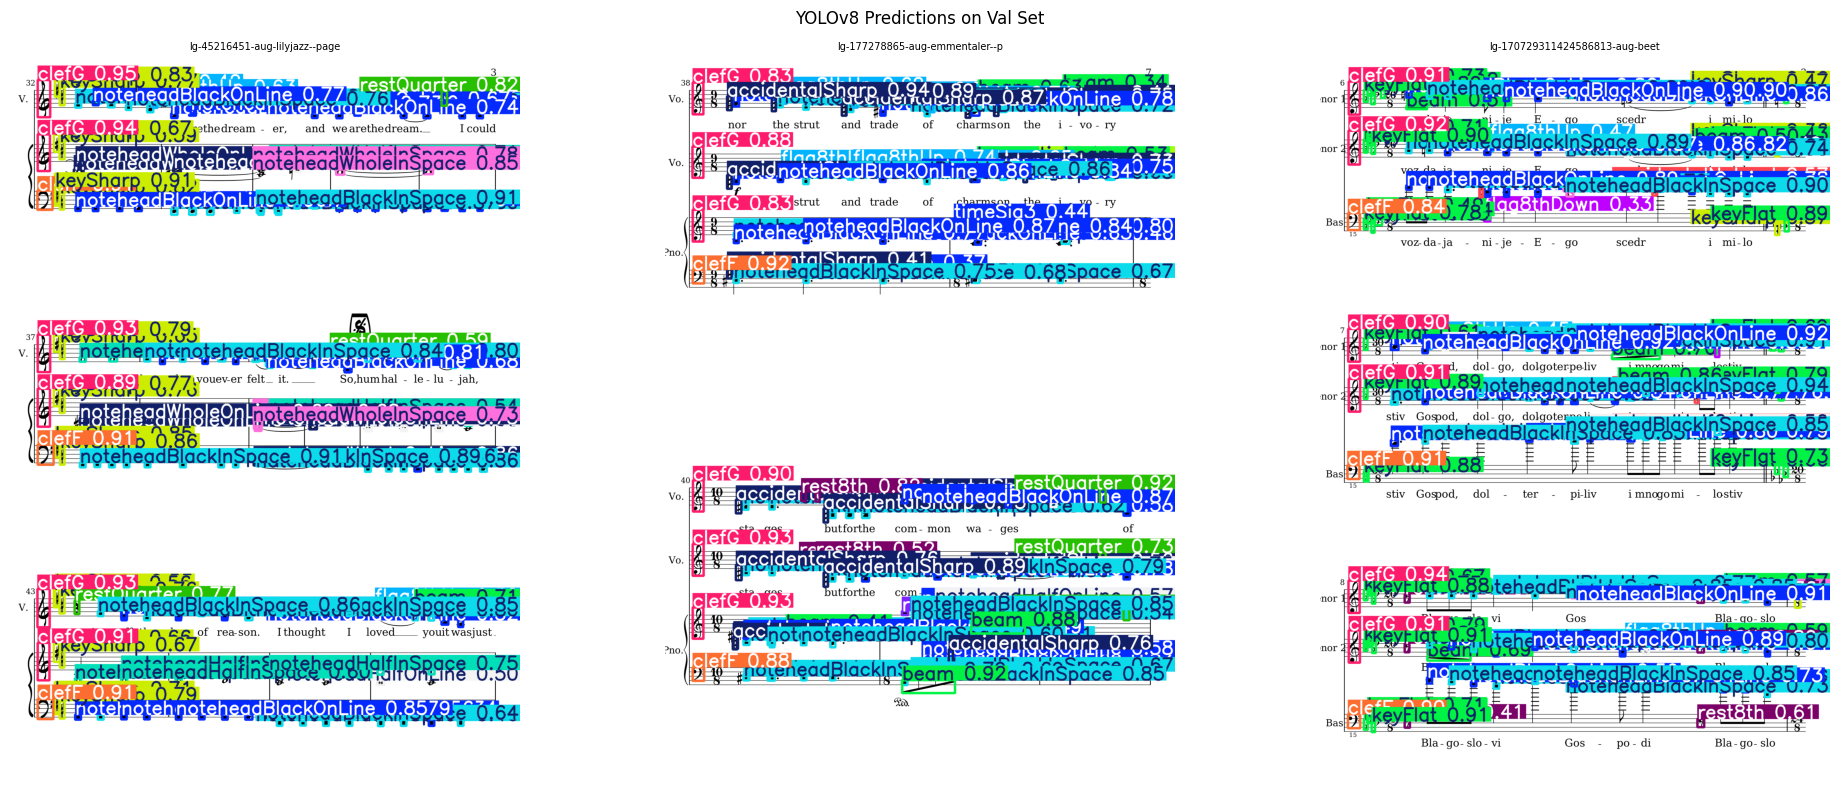

In [11]:
from PIL import Image
import numpy as np

# Run inference on 3 val images and save visualizations
sample_imgs = val_imgs[:3]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, fname in zip(axes, sample_imgs):
    img_path = f'/content/yolo_dataset/images/val/{fname}'
    results = model(img_path, conf=0.3)

    # Plot with detections
    annotated = results[0].plot()
    annotated_rgb = annotated[:, :, ::-1]  # BGR to RGB
    ax.imshow(annotated_rgb)
    ax.set_title(fname[:30], fontsize=7)
    ax.axis('off')

plt.suptitle('YOLOv8 Predictions on Val Set', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sheet_music_reader/yolo_predictions.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [13]:
IN_SCOPE = [
    'noteheadBlackOnLine', 'noteheadBlackInSpace',
    'noteheadHalfOnLine', 'noteheadHalfInSpace',
    'noteheadWholeOnLine', 'noteheadWholeInSpace',
    'ledgerLine', 'stem', 'beam',
    'flag8thDown', 'flag8thUp',
    'flag16thDown', 'flag16thUp',
    'restQuarter', 'restHalf', 'restWhole', 'rest8th',
    'clefG', 'clefF',
    'timeSig4', 'timeSig3', 'timeSig2', 'timeSigCommon', 'timeSigCutCommon',
    'accidentalSharp', 'accidentalFlat', 'accidentalNatural',
    'keySharp', 'keyFlat',
    'augmentationDot'
]
ID_TO_CLASS = {i: name for i, name in enumerate(IN_SCOPE)}
CLASS_TO_ID = {name: i for i, name in enumerate(IN_SCOPE)}

In [14]:
# Failure analysis — find images where specific classes are missed
# Focus on the three zero-AP classes

# Show what stems and ledger lines look like at 640px
from PIL import Image
import numpy as np

sample_img = Image.open(f'/content/yolo_dataset/images/val/{val_imgs[0]}')
print(f"Image size at inference: {sample_img.size}")

# Load original full-res image to compare
# The val images are already the full res ones — check actual size
img_arr = np.array(sample_img)
print(f"Array shape: {img_arr.shape}")

# Run inference and show what gets detected vs missed
results = model(f'/content/yolo_dataset/images/val/{val_imgs[0]}', conf=0.25)

detected_classes = [ID_TO_CLASS[int(c)] for c in results[0].boxes.cls.cpu().numpy()]
from collections import Counter
print("\nDetected class counts:")
for cls, cnt in Counter(detected_classes).most_common():
    print(f"  {cls:<30} {cnt}")

print("\nCompletely missed in-scope classes:")
for cls in IN_SCOPE:
    if cls not in detected_classes:
        print(f"  {cls}")

Image size at inference: (1960, 2772)
Array shape: (2772, 1960, 3)

image 1/1 /content/yolo_dataset/images/val/lg-45216451-aug-lilyjazz--page-3.png: 640x480 54 noteheadBlackOnLines, 62 noteheadBlackInSpaces, 17 noteheadHalfOnLines, 24 noteheadHalfInSpaces, 13 noteheadWholeOnLines, 9 noteheadWholeInSpaces, 1 beam, 4 flag8thUps, 3 restQuarters, 6 clefGs, 3 clefFs, 1 accidentalSharp, 22 keySharps, 12.1ms
Speed: 2.7ms preprocess, 12.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)

Detected class counts:
  noteheadBlackInSpace           62
  noteheadBlackOnLine            54
  noteheadHalfInSpace            24
  keySharp                       22
  noteheadHalfOnLine             17
  noteheadWholeOnLine            13
  noteheadWholeInSpace           9
  clefG                          6
  flag8thUp                      4
  clefF                          3
  restQuarter                    3
  beam                           1
  accidentalSharp                1

Completely m

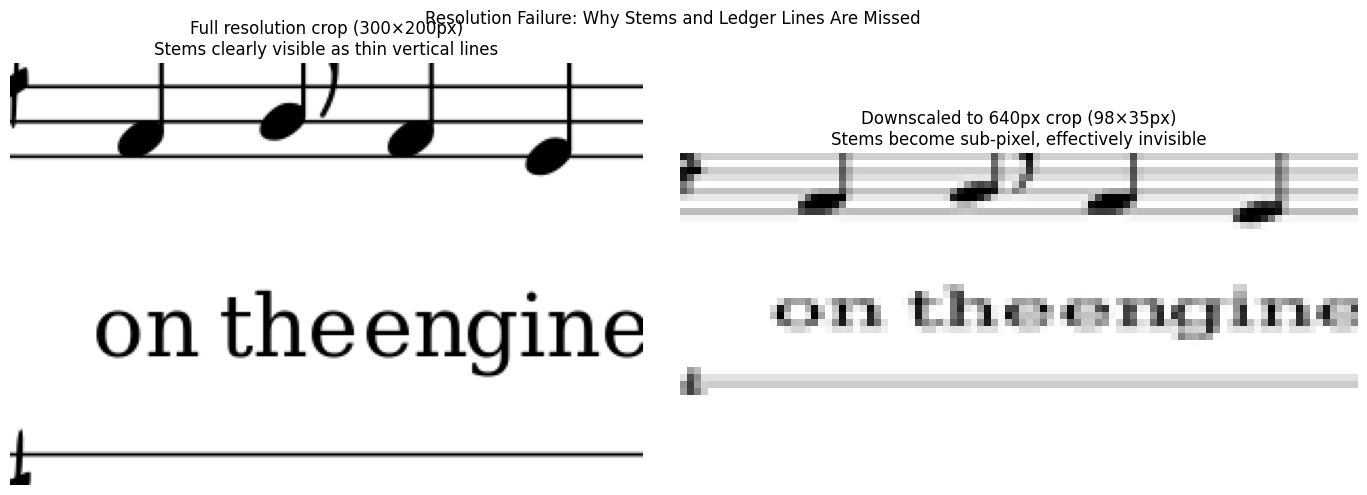

In [15]:
# Visualize the scale problem — show a crop of stems/ledger lines at full res vs resized
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_full = np.array(Image.open(
    f'/content/yolo_dataset/images/val/{val_imgs[0]}').convert('L'))
img_small = np.array(Image.open(
    f'/content/yolo_dataset/images/val/{val_imgs[0]}').convert('L').resize((640, 480)))

# Crop a small region showing stems at full res vs downscaled
# Pick a region with dense notes — upper left staff area
crop_full = img_full[150:350, 200:500]
# Same region proportionally in downscaled image
scale_x = 640 / img_full.shape[1]
scale_y = 480 / img_full.shape[0]
crop_small = img_small[
    int(150*scale_y):int(350*scale_y),
    int(200*scale_x):int(500*scale_x)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(crop_full, cmap='gray')
axes[0].set_title(f'Full resolution crop ({crop_full.shape[1]}×{crop_full.shape[0]}px)\n'
                  f'Stems clearly visible as thin vertical lines')
axes[0].axis('off')

axes[1].imshow(crop_small, cmap='gray')
axes[1].set_title(f'Downscaled to 640px crop ({crop_small.shape[1]}×{crop_small.shape[0]}px)\n'
                  f'Stems become sub-pixel, effectively invisible')
axes[1].axis('off')

plt.suptitle('Resolution Failure: Why Stems and Ledger Lines Are Missed', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sheet_music_reader/yolo_resolution_failure.png',
            dpi=150, bbox_inches='tight')
plt.show()